# What Makes a Hit? — A Spotify Data Story

**114,000 tracks. 114 genres. 31,000+ artists.**  
This is a story about music, data, and the uncomfortable truth about what it takes to be heard.

---

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Spotify-inspired palette
SPOTIFY_GREEN = '#1DB954'
SPOTIFY_BLACK = '#191414'
SPOTIFY_WHITE = '#FFFFFF'
SPOTIFY_GRAY  = '#535353'
ACCENT_PINK   = '#FF6B9D'
ACCENT_BLUE   = '#4A90D9'
ACCENT_ORANGE = '#FF8C42'

plt.rcParams.update({
    'figure.facecolor': SPOTIFY_BLACK,
    'axes.facecolor':   SPOTIFY_BLACK,
    'axes.edgecolor':   SPOTIFY_GRAY,
    'axes.labelcolor':  SPOTIFY_WHITE,
    'xtick.color':      SPOTIFY_GRAY,
    'ytick.color':      SPOTIFY_GRAY,
    'text.color':       SPOTIFY_WHITE,
    'grid.color':       '#2a2a2a',
    'grid.linestyle':   '--',
    'font.family':      'sans-serif',
    'figure.dpi':       120,
})

df = pd.read_csv('datasets/spotify_tracks_cleaned.csv')
df_unique = df.drop_duplicates('track_id')   # for track-level analysis
print(f'{len(df):,} rows | {df["track_id"].nunique():,} unique tracks | {df["artists"].nunique():,} artists | {df["track_genre"].nunique()} genres')

113,550 rows | 89,741 unique tracks | 31,437 artists | 114 genres


---
## Chapter 1 — The Lottery of Popularity

Spotify's popularity score runs from 0 to 100. It's not a lifetime measure — it's recency-weighted,  
meaning a song that blew up in 2015 but nobody streams today can score lower than a new track  
with a small but loyal fanbase.

So what does the landscape actually look like?

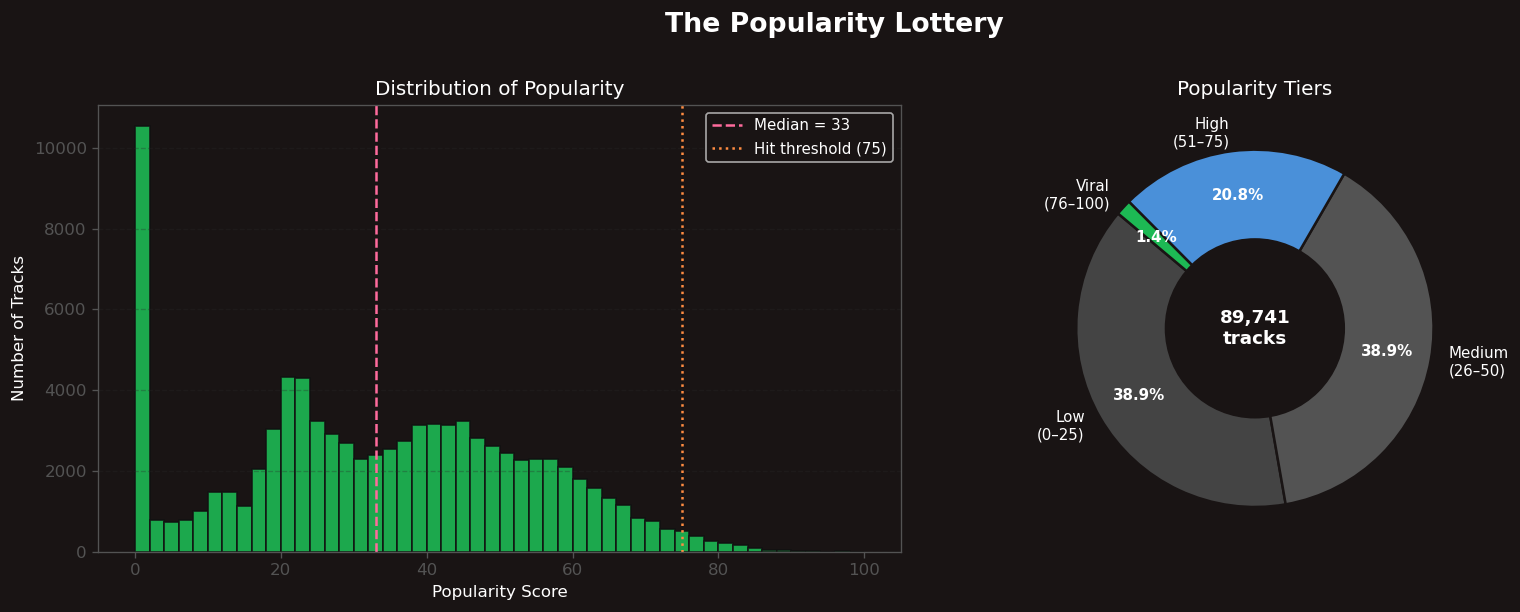

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('The Popularity Lottery', fontsize=16, fontweight='bold', color=SPOTIFY_WHITE, y=1.01)

# --- Left: histogram ---
ax = axes[0]
ax.hist(df_unique['popularity'], bins=50, color=SPOTIFY_GREEN, edgecolor='#111', alpha=0.9)
ax.axvline(df_unique['popularity'].median(), color=ACCENT_PINK, linestyle='--', lw=1.5, label=f'Median = {df_unique["popularity"].median():.0f}')
ax.axvline(75, color=ACCENT_ORANGE, linestyle=':', lw=1.5, label='Hit threshold (75)')
ax.set_xlabel('Popularity Score')
ax.set_ylabel('Number of Tracks')
ax.set_title('Distribution of Popularity', color=SPOTIFY_WHITE)
ax.legend(fontsize=9)
ax.yaxis.grid(True, alpha=0.3)

# --- Right: tier donut ---
ax2 = axes[1]
bins   = [-1, 25, 50, 75, 100]
labels = ['Low\n(0–25)', 'Medium\n(26–50)', 'High\n(51–75)', 'Viral\n(76–100)']
colors = ['#444444', SPOTIFY_GRAY, ACCENT_BLUE, SPOTIFY_GREEN]
df_unique['pop_tier'] = pd.cut(df_unique['popularity'], bins=bins, labels=labels)
sizes = df_unique['pop_tier'].value_counts().sort_index()
wedges, texts, autotexts = ax2.pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140,
    textprops={'color': SPOTIFY_WHITE, 'fontsize': 9},
    pctdistance=0.75, wedgeprops={'linewidth': 1.5, 'edgecolor': SPOTIFY_BLACK}
)
for at in autotexts:
    at.set_fontweight('bold')
centre = plt.Circle((0, 0), 0.50, color=SPOTIFY_BLACK)
ax2.add_patch(centre)
ax2.text(0, 0, f'{len(df_unique):,}\ntracks', ha='center', va='center',
         color=SPOTIFY_WHITE, fontsize=11, fontweight='bold')
ax2.set_title('Popularity Tiers', color=SPOTIFY_WHITE)

plt.tight_layout()
plt.show()

### The numbers don't lie

| Tier | Range | Tracks | Share |
|------|-------|--------|-------|
| Low | 0–25 | 44,042 | 38.8% |
| Medium | 26–50 | 41,759 | 36.8% |
| High | 51–75 | 25,337 | 22.3% |
| **Viral** | **76–100** | **2,412** | **2.1%** |

**Only 2.1% of tracks break into viral territory.** Three out of four tracks sit below 50.  
And 14% sit at exactly zero — not a mistake, just Spotify's way of saying "nobody's listening right now."

The median popularity is **35**. The average artist is not famous.

---
## Chapter 2 — The Sounds of Popularity

If you could engineer the perfect hit, what would you optimize?
Energy? Danceability? Tempo? Let's find out whether any audio feature actually predicts popularity.

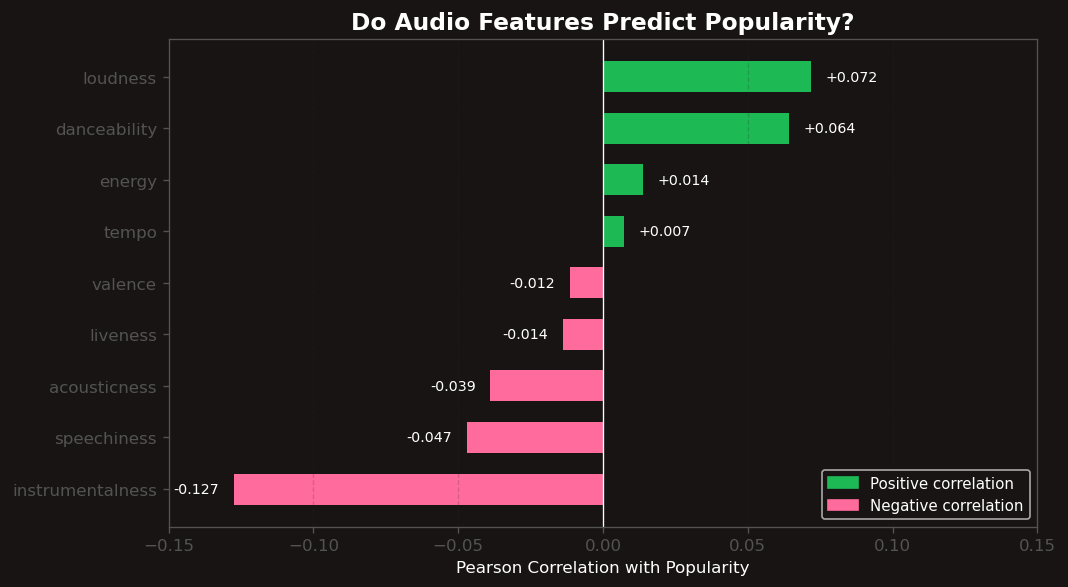

In [8]:
features = ['danceability','energy','valence','acousticness','instrumentalness',
            'speechiness','liveness','loudness','tempo']

corrs = df_unique[features + ['popularity']].corr()['popularity'].drop('popularity').sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = [SPOTIFY_GREEN if v > 0 else ACCENT_PINK for v in corrs.values]
bars = ax.barh(corrs.index, corrs.values, color=colors, edgecolor='none', height=0.6)
ax.axvline(0, color=SPOTIFY_WHITE, lw=0.8)
ax.set_xlim(-0.15, 0.15)
ax.set_xlabel('Pearson Correlation with Popularity')
ax.set_title('Do Audio Features Predict Popularity?', fontsize=14, fontweight='bold')

for bar, val in zip(bars, corrs.values):
    offset = 0.005 if val >= 0 else -0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=8.5, color=SPOTIFY_WHITE)

green_patch = mpatches.Patch(color=SPOTIFY_GREEN, label='Positive correlation')
pink_patch  = mpatches.Patch(color=ACCENT_PINK,   label='Negative correlation')
ax.legend(handles=[green_patch, pink_patch], fontsize=9, loc='lower right')
ax.xaxis.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### The uncomfortable truth

The strongest correlation between any audio feature and popularity is **instrumentalness at –0.095**.  
That's nearly nothing.

> **Audio features alone cannot predict whether a song will be popular.**

What *does* drive popularity? Playlist placement, artist fame, marketing spend, TikTok virality, label deals.  
The music itself is almost beside the point — at least statistically.

One small but real signal: **explicit tracks average 36.5 popularity vs 33.0 for clean tracks** — a modest edge  
that likely reflects genre demographics (hip-hop, dance) rather than content itself.

---
## Chapter 3 — Genre Isn't What You Think

Which genre dominates Spotify popularity? You might guess pop. You'd be wrong.

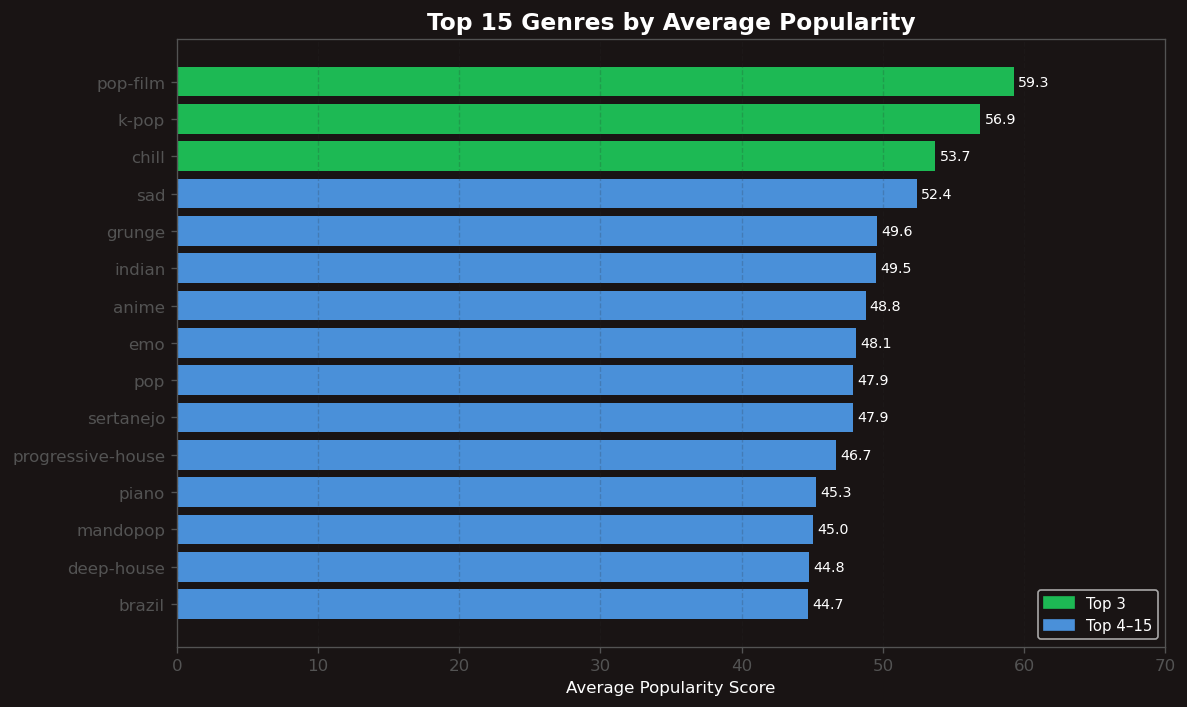

In [9]:
genre_pop = (df.groupby('track_genre')
               .agg(avg_pop=('popularity','mean'), tracks=('track_name','count'))
               .nlargest(15, 'avg_pop'))

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [SPOTIFY_GREEN if i < 3 else ACCENT_BLUE for i in range(len(genre_pop))]
bars = ax.barh(genre_pop.index[::-1], genre_pop['avg_pop'][::-1], color=bar_colors[::-1], edgecolor='none')

for bar, val in zip(bars, genre_pop['avg_pop'][::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=8.5, color=SPOTIFY_WHITE)

ax.set_xlabel('Average Popularity Score')
ax.set_title('Top 15 Genres by Average Popularity', fontsize=14, fontweight='bold')
ax.set_xlim(0, 70)
ax.xaxis.grid(True, alpha=0.2)

gold = mpatches.Patch(color=SPOTIFY_GREEN, label='Top 3')
blue = mpatches.Patch(color=ACCENT_BLUE,   label='Top 4–15')
ax.legend(handles=[gold, blue], fontsize=9)
plt.tight_layout()
plt.show()

### Pop-film? Really?

| Rank | Genre | Avg Popularity |
|------|-------|---------------|
| 1 | **pop-film** | 59.3 |
| 2 | **k-pop** | 56.9 |
| 3 | **chill** | 53.7 |
| 4 | sad | 52.4 |
| 5 | grunge | 49.6 |
| 9 | pop | 47.9 |

**Pop-film** tops the chart — music attached to film and TV has a built-in discovery engine: the story.  
**K-pop** punches way above its geographical origins, fuelled by one of the most devoted fanbases on the planet.  
**"Sad" music** at #4 is perhaps the most interesting finding: emotional resonance drives repeat listening.

---
## Chapter 4 — The Latin Takeover

Look at the top 20 most popular individual tracks in this dataset.

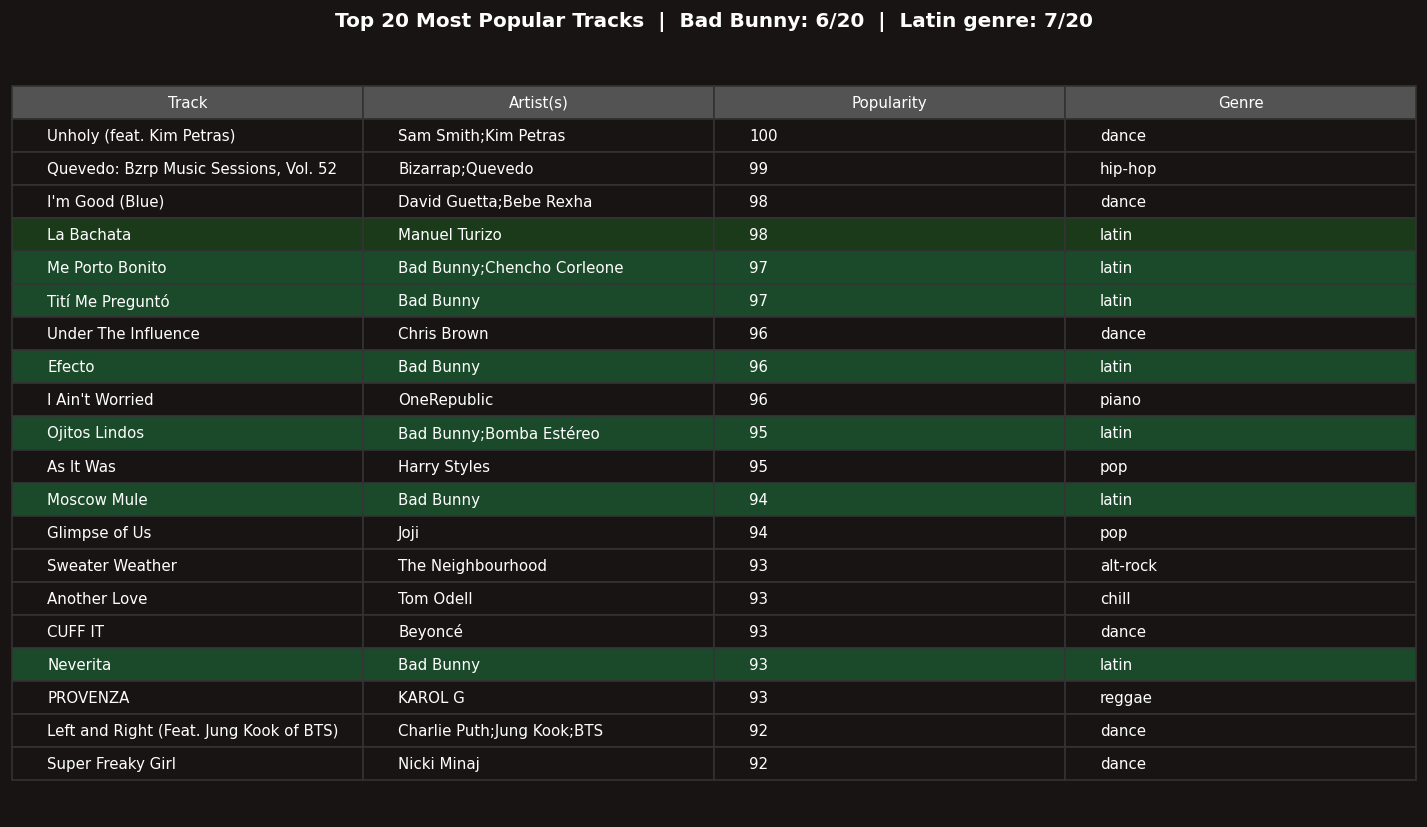

Bad Bunny appears 6 times in the top 20
Latin genre tracks: 7/20


In [10]:
top20 = df_unique.nlargest(20, 'popularity')[['track_name','artists','popularity','track_genre']].reset_index(drop=True)
top20.index += 1

# Count Bad Bunny appearances
bb_count = top20['artists'].str.contains('Bad Bunny').sum()
latin_count = (top20['track_genre'] == 'latin').sum()

fig, ax = plt.subplots(figsize=(12, 7))
ax.axis('off')

row_colors = []
for _, row in top20.iterrows():
    if 'Bad Bunny' in str(row['artists']):
        row_colors.append([SPOTIFY_GREEN + '55'] * 4)
    elif row['track_genre'] == 'latin':
        row_colors.append(['#1a3a1a'] * 4)
    else:
        row_colors.append([SPOTIFY_BLACK] * 4)

table_data = [[row['track_name'][:45], row['artists'][:35], str(row['popularity']), row['track_genre']]
              for _, row in top20.iterrows()]

tbl = ax.table(
    cellText=table_data,
    colLabels=['Track', 'Artist(s)', 'Popularity', 'Genre'],
    cellLoc='left', loc='center',
    cellColours=row_colors,
    colColours=[SPOTIFY_GRAY]*4
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.4)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#333')
    cell.set_text_props(color=SPOTIFY_WHITE)

ax.set_title(f'Top 20 Most Popular Tracks  |  Bad Bunny: {bb_count}/20  |  Latin genre: {latin_count}/20',
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(f'Bad Bunny appears {bb_count} times in the top 20')
print(f'Latin genre tracks: {latin_count}/20')

### One artist. Six slots in the top 20.

**Bad Bunny** occupies 6 of the top 20 spots. The only artist within reach of that dominance  
is the entire genre itself — latin accounts for 8 of the top 20 tracks.

The #1 track — *Unholy* by Sam Smith & Kim Petras (score: **100**) — sits in the dance genre,  
but latin music defines the tier just below it. The global shift in music is not coming — it's here.

---
## Chapter 5 — The Physics of Music

Even if audio features can't predict hits, they tell us something deep about how music is structured.  
Some relationships between features are almost laws of physics.

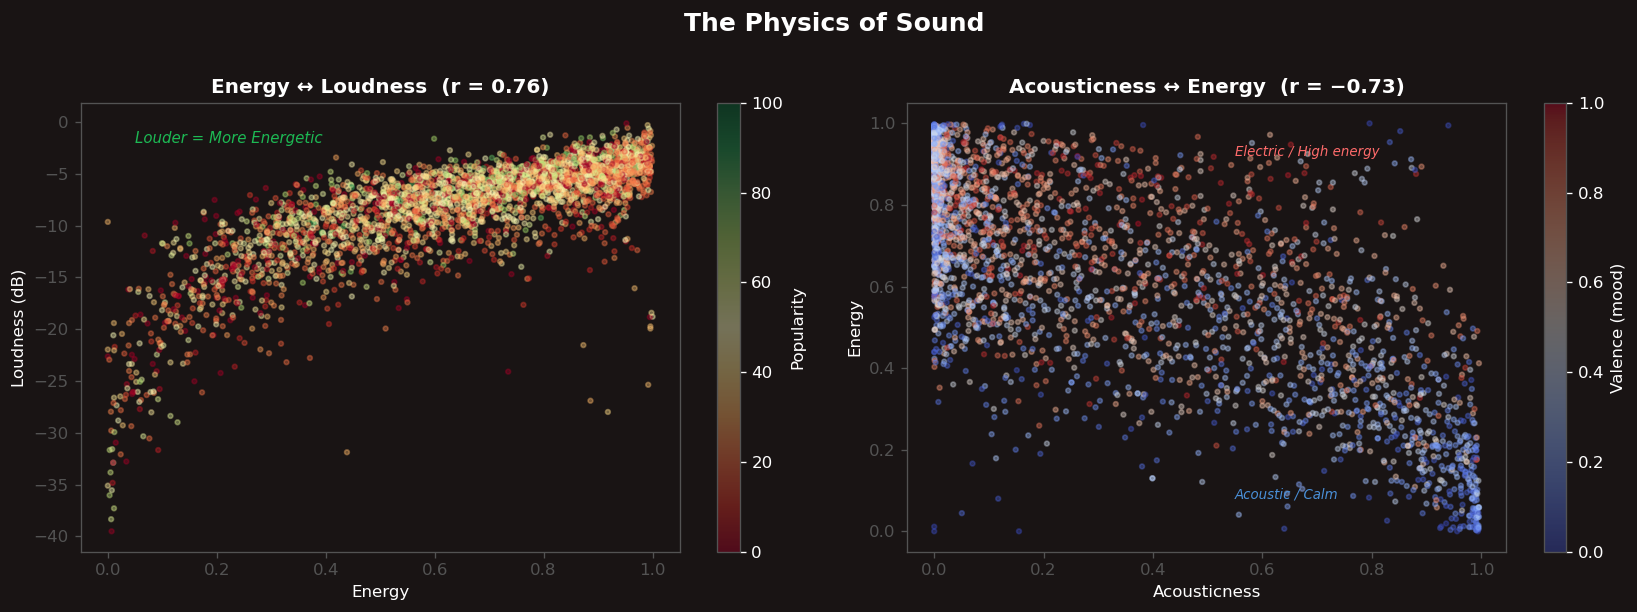

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('The Physics of Sound', fontsize=15, fontweight='bold', y=1.01)

# --- Energy vs Loudness (r ≈ 0.76) ---
ax = axes[0]
sample = df_unique.sample(3000, random_state=42)
scatter = ax.scatter(sample['energy'], sample['loudness'],
                     c=sample['popularity'], cmap='RdYlGn',
                     alpha=0.4, s=8, vmin=0, vmax=100)
cb = plt.colorbar(scatter, ax=ax)
cb.set_label('Popularity', color=SPOTIFY_WHITE)
cb.ax.yaxis.set_tick_params(color=SPOTIFY_WHITE)
plt.setp(plt.getp(cb.ax.axes, 'yticklabels'), color=SPOTIFY_WHITE)
ax.set_xlabel('Energy')
ax.set_ylabel('Loudness (dB)')
ax.set_title('Energy ↔ Loudness  (r = 0.76)', fontweight='bold')
ax.text(0.05, -2, 'Louder = More Energetic', color=SPOTIFY_GREEN, fontsize=9, style='italic')

# --- Energy vs Acousticness (r ≈ -0.73) ---
ax2 = axes[1]
scatter2 = ax2.scatter(sample['acousticness'], sample['energy'],
                       c=sample['valence'], cmap='coolwarm',
                       alpha=0.4, s=8, vmin=0, vmax=1)
cb2 = plt.colorbar(scatter2, ax=ax2)
cb2.set_label('Valence (mood)', color=SPOTIFY_WHITE)
cb2.ax.yaxis.set_tick_params(color=SPOTIFY_WHITE)
plt.setp(plt.getp(cb2.ax.axes, 'yticklabels'), color=SPOTIFY_WHITE)
ax2.set_xlabel('Acousticness')
ax2.set_ylabel('Energy')
ax2.set_title('Acousticness ↔ Energy  (r = −0.73)', fontweight='bold')
ax2.text(0.55, 0.92, 'Electric / High energy', color='#FF6B6B', fontsize=8, style='italic')
ax2.text(0.55, 0.08, 'Acoustic / Calm', color=ACCENT_BLUE, fontsize=8, style='italic')

plt.tight_layout()
plt.show()

### Two laws of music:

1. **Energy ↔ Loudness (r = +0.76):** The louder a track, the more energetic it feels. Not a surprise, but  
   the strength of this relationship is remarkable — these are essentially measuring the same underlying quality.

2. **Acousticness ↔ Energy (r = −0.73):** Acoustic and electric exist on a nearly perfect spectrum.  
   A track either plugs in or it doesn't. Very few live in the middle — the distribution of acousticness is **bimodal**.

Notice that neither relationship has much to say about popularity (the color in the left chart is scattered uniformly).  
Physics doesn't care about fame.

---
## Chapter 6 — Happy vs Sad: A Genre Mood Map

Spotify's **valence** score measures musical positivity — 1.0 is euphoric, 0.0 is bleak.  
Combined with energy, it maps every genre onto a four-quadrant mood space.

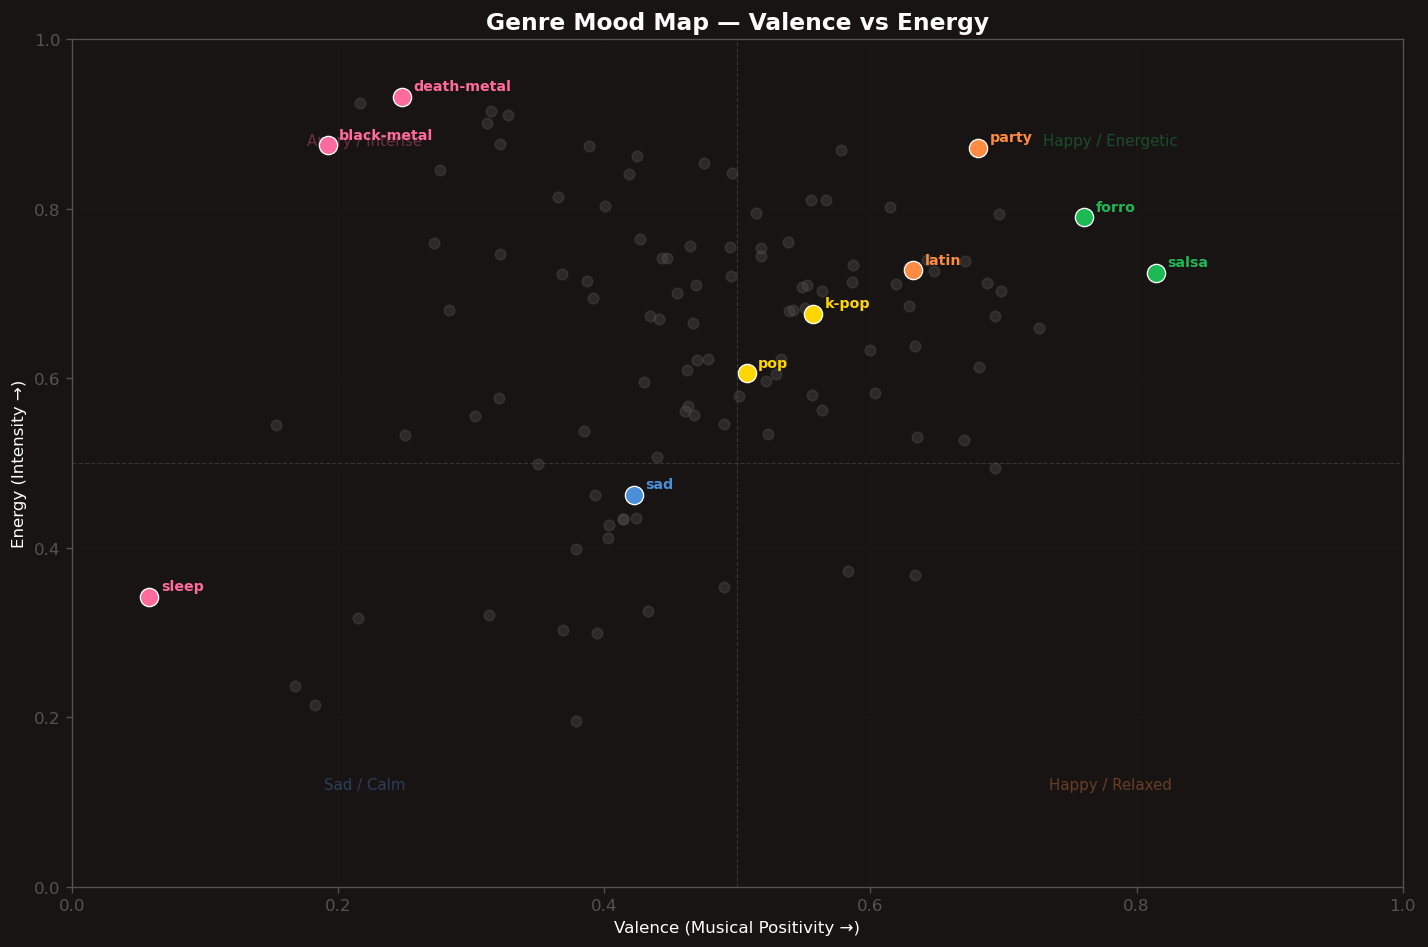

In [12]:
genre_mood = df.groupby('track_genre').agg(
    avg_valence=('valence', 'mean'),
    avg_energy=('energy', 'mean'),
    avg_pop=('popularity', 'mean'),
    tracks=('track_name', 'count')
).query('tracks > 100')

# Spotlight genres
highlight = {
    'salsa': SPOTIFY_GREEN,
    'forro': SPOTIFY_GREEN,
    'sleep': ACCENT_PINK,
    'black-metal': ACCENT_PINK,
    'death-metal': ACCENT_PINK,
    'party': ACCENT_ORANGE,
    'sad': ACCENT_BLUE,
    'pop': '#FFD700',
    'k-pop': '#FFD700',
    'latin': ACCENT_ORANGE,
}

fig, ax = plt.subplots(figsize=(12, 8))

# Background points
mask_bg = ~genre_mood.index.isin(highlight.keys())
ax.scatter(genre_mood.loc[mask_bg, 'avg_valence'],
           genre_mood.loc[mask_bg, 'avg_energy'],
           c=SPOTIFY_GRAY, alpha=0.35, s=40, zorder=2)

# Highlighted genres
for genre, color in highlight.items():
    if genre in genre_mood.index:
        row = genre_mood.loc[genre]
        ax.scatter(row['avg_valence'], row['avg_energy'],
                   c=color, s=120, zorder=4, edgecolors='white', linewidths=0.8)
        ax.annotate(genre, (row['avg_valence'], row['avg_energy']),
                    xytext=(7, 4), textcoords='offset points',
                    fontsize=8.5, color=color, fontweight='bold')

# Quadrant lines and labels
ax.axvline(0.5, color=SPOTIFY_GRAY, lw=0.7, alpha=0.5, linestyle='--')
ax.axhline(0.5, color=SPOTIFY_GRAY, lw=0.7, alpha=0.5, linestyle='--')
quad_kw = dict(fontsize=9, alpha=0.35, va='center', ha='center')
ax.text(0.22, 0.88, 'Angry / Intense', **quad_kw, color=ACCENT_PINK)
ax.text(0.78, 0.88, 'Happy / Energetic', **quad_kw, color=SPOTIFY_GREEN)
ax.text(0.22, 0.12, 'Sad / Calm', **quad_kw, color=ACCENT_BLUE)
ax.text(0.78, 0.12, 'Happy / Relaxed', **quad_kw, color=ACCENT_ORANGE)

ax.set_xlabel('Valence (Musical Positivity →)')
ax.set_ylabel('Energy (Intensity →)')
ax.set_title('Genre Mood Map — Valence vs Energy', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.show()

### Four emotional corners of music:

| Quadrant | Character | Examples |
|----------|-----------|----------|
| Top-right | Happy + Energetic | salsa, forro, party, latin |
| Top-left | Intense + Dark | death-metal, black-metal |
| Bottom-right | Happy + Calm | kids, acoustic |
| Bottom-left | Sad + Calm | sleep, ambient, new-age |

**Sleep** is the loneliest point on the chart — low valence, low energy — music designed to  
accompany unconsciousness. **Salsa** and **forro** anchor the opposite corner, the genres that make you move.

What's striking: **pop** and **k-pop** sit comfortably in the center-right — broadly appealing,  
neither too intense nor too passive. That's not a coincidence.

---
## Chapter 7 — Does Length Matter?

In the streaming era, does anyone have patience for a long song?

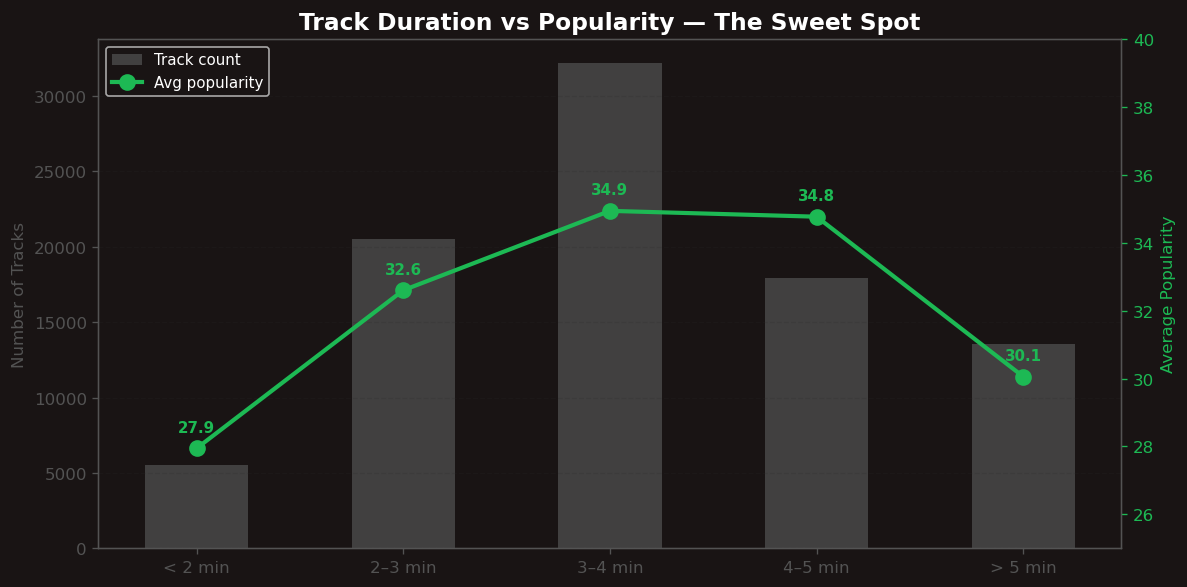

In [13]:
df_unique = df_unique.copy()
df_unique['dur_min'] = df_unique['duration_ms'] / 60000
bins   = [0, 2, 3, 4, 5, 100]
labels = ['< 2 min', '2–3 min', '3–4 min', '4–5 min', '> 5 min']
df_unique['dur_bucket'] = pd.cut(df_unique['dur_min'], bins=bins, labels=labels)
dur_stats = df_unique.groupby('dur_bucket', observed=True).agg(
    tracks=('popularity','count'),
    avg_pop=('popularity','mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

x = range(len(dur_stats))
bars = ax1.bar(x, dur_stats['tracks'], color=SPOTIFY_GRAY, alpha=0.7, width=0.5, label='Track count')
line, = ax2.plot(x, dur_stats['avg_pop'], color=SPOTIFY_GREEN, marker='o', lw=2.5,
                 markersize=9, label='Avg popularity')

for xi, val in zip(x, dur_stats['avg_pop']):
    ax2.annotate(f'{val:.1f}', (xi, val), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=9, color=SPOTIFY_GREEN, fontweight='bold')

ax1.set_xticks(list(x))
ax1.set_xticklabels(labels)
ax1.set_ylabel('Number of Tracks', color=SPOTIFY_GRAY)
ax2.set_ylabel('Average Popularity', color=SPOTIFY_GREEN)
ax2.tick_params(axis='y', colors=SPOTIFY_GREEN)
ax2.set_ylim(25, 40)
ax1.set_title('Track Duration vs Popularity — The Sweet Spot', fontsize=14, fontweight='bold')

lines_labels = [ax1.get_legend_handles_labels(), ax2.get_legend_handles_labels()]
handles = [bars, line]
ax1.legend(handles, ['Track count', 'Avg popularity'], fontsize=9, loc='upper left')
ax1.yaxis.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### The sweet spot is 3–5 minutes

| Duration | Avg Popularity |
|----------|---------------|
| Under 2 min | 28.6 |
| 2–3 min | 32.2 |
| **3–4 min** | **34.8** |
| **4–5 min** | **34.8** |
| Over 5 min | 31.2 |

Songs between 3–5 minutes sit at the top. Too short and you don't give listeners enough to connect with.  
Too long and you lose them.

The radio edit format — a 3–4 minute song — turns out to be as mathematically correct in the streaming age  
as it was in the AM radio era.

---
## Chapter 8 — What Genre Has the Most "Vibe"?

Define *vibe* as the average of danceability + energy + valence.  
Which genres make you move, feel good, and turn up simultaneously?

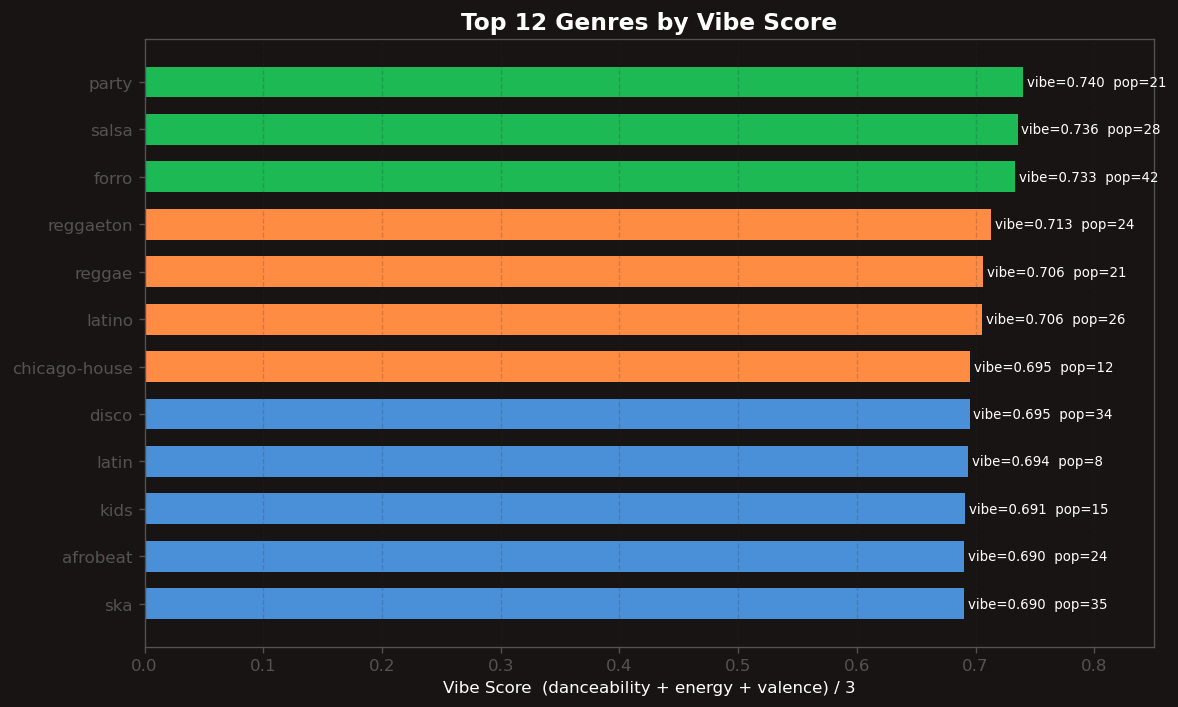

In [14]:
df['vibe'] = (df['danceability'] + df['energy'] + df['valence']) / 3
genre_vibe = (df.groupby('track_genre')
                .agg(vibe=('vibe','mean'), tracks=('track_name','count'), avg_pop=('popularity','mean'))
                .query('tracks > 100')
                .nlargest(12, 'vibe'))

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [SPOTIFY_GREEN]*3 + [ACCENT_ORANGE]*4 + [ACCENT_BLUE]*5
bars = ax.barh(genre_vibe.index[::-1], genre_vibe['vibe'][::-1],
               color=bar_colors[::-1], edgecolor='none', height=0.65)

for bar, val, pop in zip(bars, genre_vibe['vibe'][::-1], genre_vibe['avg_pop'][::-1]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'vibe={val:.3f}  pop={pop:.0f}', va='center', fontsize=8, color=SPOTIFY_WHITE)

ax.set_xlabel('Vibe Score  (danceability + energy + valence) / 3')
ax.set_title('Top 12 Genres by Vibe Score', fontsize=14, fontweight='bold')
ax.set_xlim(0, 0.85)
ax.xaxis.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### Vibe ≠ Popularity

**Party, salsa, and forro** top the vibe chart — yet none of them crack the top 5 genres by popularity.  
The most infectious music isn't always the most streamed.

This gap between vibe and popularity reinforces what we saw in Chapter 2:  
streaming success is driven by discovery infrastructure, not sonic quality.

---
## Epilogue — The Full Picture

Six chapters, six findings. Here's what 114,000 tracks taught us:

| # | Finding |
|---|--------|
| 1 | **Only 2.1% of tracks go viral.** The music industry is a lottery, and most tickets lose. |
| 2 | **Audio features can't predict popularity.** The strongest signal — instrumentalness — explains less than 1% of variance. |
| 3 | **Pop-film and K-pop outperform "pop".** Story and fandom beat genre labels. |
| 4 | **Bad Bunny holds 6 of the top 20 spots.** Latin music is the defining force in contemporary streaming. |
| 5 | **The 3–5 minute sweet spot is real.** Even in the era of 30-second TikToks, a proper song-length still wins. |
| 6 | **Vibe and popularity diverge.** The most energetic, joyful music isn't the most streamed — distribution is. |

---

> *The dataset is balanced (1,000 tracks per genre), so frequency comparisons across genres are fair.  
> Popularity scores reflect Spotify's recency-weighted algorithm at the time of dataset creation.*